# Лабораторная работа №3

In [1]:
import pandas as pd
import sklearnex

from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
sklearnex.patch_sklearn()

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.svm import LinearSVC
from sklearnex.svm import SVC
from sklearnex.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline

import optuna
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, \
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

RANDOM_STATE = 13

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("datasets/neo.csv", index_col="Unnamed: 0")
data

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,-0.889019,-0.892421,0.316109,-1.612480,0.892109,0
1,-0.405274,-0.407831,-1.593181,-0.196165,0.406521,0
2,0.043918,0.042145,0.286110,1.266990,-0.044382,0
3,-0.750806,-0.753967,-0.258175,-1.094244,0.753369,0
4,0.734983,0.734416,0.777089,1.531822,-0.738079,0
...,...,...,...,...,...,...
90831,-0.819912,-0.823194,-0.982506,-1.585159,0.822739,0
90832,0.562217,0.561348,-0.921528,-0.158712,-0.564655,0
90833,-0.301614,-0.303991,2.706200,0.789522,0.302466,0
90834,-0.128848,-0.130923,-0.090366,-0.452655,0.129042,0


In [3]:
data["hazardous"].value_counts()

hazardous
0    81996
1     8840
Name: count, dtype: int64

Text(0, 0.5, 'counts')

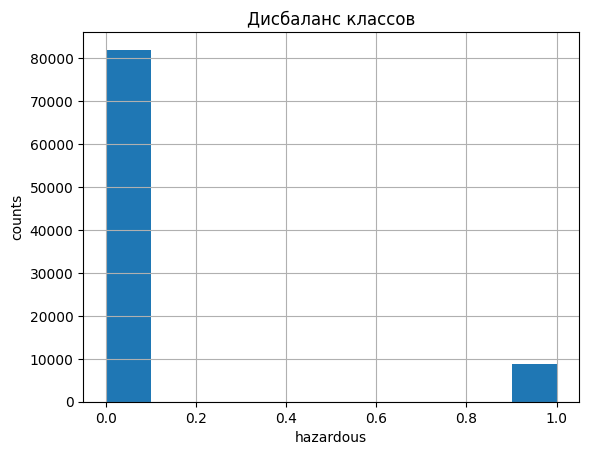

In [5]:
data["hazardous"].hist()
plt.title("Дисбаланс классов")
plt.xlabel("hazardous")
plt.ylabel("counts")

Существует большой дисбаланс классов. Количество неопасных объектов гораздо больше количества опасных объектов. В качестве мажоритарного класса выступает класс опасных метеоритов (81996 объектов), а в качестве миноритарного - класс неопасных метеоритов (8840 объектов).

## Разделение выборки и балансировка классов

Разделим генеральную выборку на тренировчную, валидационную и тестовую в соотношении 80 - 10 - 10, сохраняя баланс классов с помощью параметра `stratify`.

In [4]:
random_state = 13
X = data.drop("hazardous", axis=1)
y = data["hazardous"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state = RANDOM_STATE, stratify=y)
X_test, X_val, y_test, y_val  = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state = RANDOM_STATE, stratify=y_val_test)

print(f"Размер исходной выборки: {len(X)}\n"
      f"Размер тренировочной выборки: {len(X_train)}\n"
      f"Размер валидационной выборки: {len(X_val)}\n"
      f"Размер тестовой выборки: {len(X_test)}")

Размер исходной выборки: 90836
Размер тренировочной выборки: 72668
Размер валидационной выборки: 9084
Размер тестовой выборки: 9084


Для решения проблемы дисбаланса классов применим стратегию over-sampling для синтетического увеличения количества объектов миноритарного класса.

Количество объектов мажоритарного класса в 10 раз превосходит количество объектов миноритарного класса. При использовании стратегии under-sampling существенное количество данных о неопасных объектов не было бы применено для модели. Это может привести к потери важной информации о поведении модели.

In [5]:
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"Размер сбалансированной выборки: {len(X_train_res)}")

Размер сбалансированной выборки: 131192


Количество объектов после применения `SMOTE` значительно увеличилось более, чем на 40 тысяч объектов. Посмотрим на распределение классов в выборке после применения стратегии over-sampling.

In [10]:
print("Доля классов в исходных данных:\n", y.value_counts(normalize=True))
print("\nДоля в тренировочной выборке:\n", y_train_res.value_counts(normalize=True))
print("\nДоля в валидационной выборке:\n", y_val.value_counts(normalize=True))
print("\nДоля в тестовой выборке:\n", y_test.value_counts(normalize=True))

Доля классов в исходных данных:
 hazardous
0    0.902682
1    0.097318
Name: proportion, dtype: float64

Доля в тренировочной выборке:
 hazardous
0    0.5
1    0.5
Name: proportion, dtype: float64

Доля в валидационной выборке:
 hazardous
0    0.902686
1    0.097314
Name: proportion, dtype: float64

Доля в тестовой выборке:
 hazardous
0    0.902686
1    0.097314
Name: proportion, dtype: float64


После применения сэмплирования баланс классов был восстановлен до 50/50. Заметим, что стратегия сэмплирования была применена только для тренировочной выборки, так тестирование модели не должно проводиться на синтетических данных для того, чтобы понять реальную обобщающую способность модели.

## Подготовка к обучению модели

In [11]:
def train_models_with_val(X_train, y_train, X_val, y_val, models_config):

    result={}

    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        model_class = model_info["model"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=model_class(),
            scoring="f1",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=model_class(),
            scoring="f1",
            random_state=RANDOM_STATE,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            model = model_class(**trial_params)
            model.fit(X_train, y_train)
            score = f1_score(y_val, model.predict(X_val)) # максимизируем на валидационной выборке
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=15, show_progress_bar=False)

        optuna_model = model_class(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result

Для применения настройки параметров через кросс-валидацию будем использовать раздление тренировочной выборки на 10 фолдов.

In [9]:
def train_models_with_cross_val(X_train, y_train, models_config):

    result={}

    skf = StratifiedKFold(n_splits=10, random_state=RANDOM_STATE, shuffle=True)
    smote = SMOTE(random_state=RANDOM_STATE)

    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        model_obj = model_info["model"]
        prefixed_param_grid = {f"model__{k}": v for k, v in param_grid.items()}

        pipeline = Pipeline([('smote', smote), ('model', model_obj())])
        grid_search_model = GridSearchCV(
            param_grid=prefixed_param_grid,
            estimator= pipeline,
            scoring="f1",
            cv=skf
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=prefixed_param_grid,
            estimator=pipeline,
            scoring="f1",
            random_state=RANDOM_STATE,
            cv=skf
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            current_pipe = Pipeline([
                ('smote', smote),
                ('model', model_obj(**trial_params,random_state=RANDOM_STATE))
            ])

            score = cross_val_score(current_pipe, X_train, y_train, cv=skf, scoring='f1').mean()
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=5, show_progress_bar=False)

        final_optuna_pipe = Pipeline([
                ('smote', smote),
                ('model', model_obj(**study.best_params,random_state=RANDOM_STATE))
            ])
        final_optuna_pipe.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": final_optuna_pipe,
            "best_params": study.best_params
        }

    return result

Создадим таблицы для сравнения метрик моделей.

In [6]:
columns1 = []
columns2 = []

metrics = ["F1", "Accuracy", "Precision", "Recall"]
for type_of_data in ["Train Data", "Test Data"]:
    for metric in metrics:
        columns1.append(type_of_data + " " + metric)

for type_of_division in ["Метод hold-out", "Метод k-fold"]:
    for metric in metrics:
        columns2.append(type_of_division + " " + metric)

train_test_table = pd.DataFrame(columns=columns1)
hold_kfold_table = pd.DataFrame(columns=columns2)
train_test_table

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall


In [28]:
hold_kfold_table

,Метод hold-out F1,Метод hold-out Accuracy,Метод hold-out Precision,Метод hold-out Recall,Метод k-fold F1,Метод k-fold Accuracy,Метод k-fold Precision,Метод k-fold Recall


In [10]:
def get_metrics(y_test, y_predicted, print_results=False):
    names_of_metrics = ["F1", "Accuracy", "Precision", "Recall"]
    results = [
        round(f1_score(y_test, y_predicted), 2),
        round(accuracy_score(y_test, y_predicted), 4),
        round(precision_score(y_test, y_predicted), 4),
        round(recall_score(y_test, y_predicted), 4)
    ]

    if print_results:
        for name, result in zip(names_of_metrics, results):
            print(f"{name}: {result}")

    return results

In [9]:
def input_metrics_into_the_train_test_table(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test):
    sk_learn_test_metrics = get_metrics(y_test, predict_on_test_y)

    sk_learn_train_metrics = get_metrics(y_train, predict_on_train_y)

    train_test_table.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics

In [19]:
def get_cv_report(model, X, y, random_state=42):

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)

    results = []


    for i, (_, test_index) in enumerate(skf.split(X, y)):

        X_fold = X.iloc[test_index] if hasattr(X, 'iloc') else X[test_index]
        y_fold = y.iloc[test_index] if hasattr(y, 'iloc') else y[test_index]


        y_pred = model.predict(X_fold)


        results.append({
            'Fold': f'Fold {i+1}',
            'Accuracy': accuracy_score(y_fold, y_pred),
            'Prec.': precision_score(y_fold, y_pred, zero_division=0),
            'Recall': recall_score(y_fold, y_pred, zero_division=0),
            'F1': f1_score(y_fold, y_pred, zero_division=0)
        })


    df = pd.DataFrame(results).set_index('Fold')


    stats = pd.DataFrame({
        'Accuracy': [df['Accuracy'].mean(), df['Accuracy'].std()],
        'Prec.': [df['Prec.'].mean(), df['Prec.'].std()],
        'Recall': [df['Recall'].mean(), df['Recall'].std()],
        'F1': [df['F1'].mean(), df['F1'].std()]
    }, index=['Mean', 'Std'])

    return pd.concat([df, stats]).round(4)

## Обучение моделей

Используем следующие алгоритмы для обучения моделей:

* Логистическая регрессия
* kNN (с 3 различными метриками)
* Байесовская регрессия
* SVM с линейным, полиномиальным, радиальным и сигмоидным ядрами

In [8]:
models_grid = {
    "Logistic regression":{
        "model": LogisticRegression,
        "param_grid":
            {
                "C": [0.1, 1, 10, 100],
                "penalty": ["l2"],
                "solver": ["lbfgs"]

            }
    },
    "KNN_euclidean":
        {
            "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["euclidean"]
            }
        },
    "KNN_manhattan":{
            "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["manhattan"]
            }
        },
    "KNN_chebyshev":{
        "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["chebyshev"]
            }
    },

    "Naive_Bayes":{
        "model": GaussianNB,
        "param_grid":{
            "var_smoothing": np.logspace(-3, 1, num=20)
        }
    },

    "SVM_linear":{
        "model": LinearSVC,
        "param_grid":{
            "C": [0.1, 1, 10],
        }
    },
    "SVM_poly":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale"],
            "cache_size": [4000],
            "kernel": ["poly"],
            "degree": [2]
        }
    },

    "SVM_rbf":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale"],
            "kernel": ["rbf"],
            "cache_size": [4000],
        }
    },

     "SVM_sigmoid":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale"],
            "kernel": ["sigmoid"],
             "cache_size": [4000],
        }
    },
}

In [15]:
val_models = train_models_with_val(X_train_res, y_train_res, X_val, y_val, models_grid)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[I 2026-04-04 15:42:52,062] A new study created in memory with name: no-name-0aac1322-b457-4e21-9625-ccdadb3298f0
[I 2026-04-04 15:42:52,164] Trial 0 finished with value: 0.4526912181303116 and parameters: {'C': 2.9614647330288024, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.4526912181303116.
[I 2026-04-04 15:42:52,266] Trial 1 finished with value: 0.4525630133106769 and parameters: {'C': 0.13750113153466934, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.4526912181303116.
[I 2026-04-04 15:42:52,368] Trial 2 finished with value: 0.4525630133106769 and parameters: {'C': 0.13153705568430027, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.4526912181303116.
[I 2026-

In [20]:
cross_val_models = train_models_with_cross_val(X_train, y_train, models_grid)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[I 2026-04-04 16:41:02,470] A new study created in memory with name: no-name-b898e617-2622-4ed7-be28-43fae72e5005
[I 2026-04-04 16:41:03,649] Trial 0 finished with value: 0.45748750290980345 and parameters: {'C': 12.70959651009709, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.45748750290980345.
[I 2026-04-04 16:41:04,767] Trial 1 finished with value: 0.45748750290980345 and parameters: {'C': 22.091157345362454, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 0 with value: 0.45748750290980345.
[I 2026-04-04 16:41:06,015] Trial 2 finished with value: 0.45748834590727105 and parameters: {'C': 0.16141871220045184, 'penalty': 'l2', 'solver': 'lbfgs'}. Best is trial 2 with value: 0.45748834590727105.
[I 2

In [7]:
import pickle
with open("all_val_models_results.pkl", "rb") as file:
    val_models = pickle.load(file)

with open("all_cv_models_results.pkl", "rb") as file:
    cross_val_models = pickle.load(file)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GaussianNB from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimat

Вставим в таблицу информацию о моделях, полученных с помощью настройки гиперпараметров через валидационную выборку и через кросс-валидацию.

In [13]:
for alg, search_info in val_models.items():
    for type_of_search, model_info in search_info.items():
        model = model_info["model"]
        y_test_predicted = model.predict(X_test)
        y_train_predicted = model.predict(X_train)

        name_of_model = f"{alg} with validation ({type_of_search})"
        
        input_metrics_into_the_train_test_table(name_of_model,
                              y_train_predicted, y_train,
                              y_test_predicted, y_test)
train_test_table.sort_values(by="Test Data F1", ascending=False)

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall
KNN_manhattan with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.50,0.8296,0.3483,0.8620
KNN_euclidean with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.49,0.8343,0.3479,0.8032
KNN_manhattan with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8646,0.3837,0.6459
KNN_manhattan with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8646,0.3837,0.6459
KNN_chebyshev with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.48,0.8181,0.3322,0.8597
KNN_euclidean with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.47,0.8591,0.3718,0.6493
KNN_euclidean with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.47,0.8591,0.3718,0.6493
KNN_chebyshev with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.46,0.8517,0.3572,0.6550
SVM_rbf with validation (GridSearch),0.46,0.7756,0.3017,0.9934,0.46,0.7780,0.3030,0.9853
SVM_rbf with validation (Optuna),0.46,0.7755,0.3016,0.9934,0.46,0.7780,0.3030,0.9853


In [14]:
for alg, search_info in cross_val_models.items():
    for type_of_search, model_info in search_info.items():
        model = model_info["model"]
        y_test_predicted = model.predict(X_test)
        y_train_predicted = model.predict(X_train)

        name_of_model = f"{alg} with cross-validation ({type_of_search})"

        input_metrics_into_the_train_test_table(name_of_model,
                              y_train_predicted, y_train,
                              y_test_predicted, y_test)
train_test_table.sort_values(by="Test Data F1", ascending=False)

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall
KNN_manhattan with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.50,0.8296,0.3483,0.8620
KNN_manhattan with cross-validation (Optuna),1.00,1.0000,1.0000,1.0000,0.50,0.8296,0.3483,0.8620
KNN_manhattan with cross-validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.49,0.8400,0.3557,0.7930
KNN_manhattan with cross-validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.49,0.8400,0.3557,0.7930
KNN_euclidean with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.49,0.8343,0.3479,0.8032
KNN_chebyshev with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.48,0.8181,0.3322,0.8597
KNN_euclidean with cross-validation (Optuna),1.00,1.0000,1.0000,1.0000,0.48,0.8225,0.3379,0.8586
KNN_euclidean with cross-validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8225,0.3379,0.8586
KNN_chebyshev with cross-validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8181,0.3322,0.8597
KNN_euclidean with cross-validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8225,0.3379,0.8586


Стоит отметить, что для всех моделей KNN, обученных на данных, сбалансированных с помощью SMOTE, характерно переобучение. Так, для всех моделей метрика F1 на тренировочных данных не ниже 0.7, но на тестовых данных F1 не выше 0.5.

Лучшей моделью оказалась KNN с манхеттенской метрикой, гиперпараметры который были получены при помощи кросс-валидации через фреймворк Optuna. Стоит отметить, что лучшими моделями по метрике F1 оказались модели KNN с любыми метриками расстояния (F1 принимает значение от 0.46 до 0.50). Заметим, что модели KNN на тренировочной выборке работают идеально, но при этом они значительно хуже работают на тестовой выборке.

Кроме KNN, хорошо себя показал алгоритм SVC с радиально-базисным ядром (для него метрика f1 принимает значение 0.46).

Прочие алгоритмы отработали примерно с тем же значением метрики: для наивной баейсовской модели, SVM с линейным ядром и логистической регрессии метрика f1 принимает значение 0.46.

Модели SVM с полиномиальным и сигмоидным ядрами отработали значительно хуже - для них метрика f1 принимает значение 0.25.

Стоит отметить, что модели, работающие на основе одних и тех же алгоритмов, при настройке гиперпараметров при помощи валидации и кросс-валидации дают практически одни и те же метрики (модель, полученная при помощи кросс-валидации, может иметь немного лучшие метрики, как например, наивная байесовская модель с Accuracy 0.7704 с кросс-валидацией и 0.7604 с валидационной выборкой). Это объясняется тем, что суть алгоритма кросс-валидации не предполагает фиксированного набора данных для обучения, так как данные делятся на фолды и модель последовательно обучается на каждом из них.


На основе метрик выберем лучшие модели для каждого алгоритма. В дальнейшем будем рассматривать их.

Стоит отметить, что наиболее важной метрикой для данного датасета является Recall.

В контексте предметной области recall показывает отношение верно идентифицированных опасных объектов к числу всех объектов, которые были сочтены моделью как опасные. Это означает, при высоком recall модель хорошо находит опасные объекты.

Precision же показывает отношение верно идентифицированных опасных объектов к сумме верно идентифицированных опасных объектов и объектов, которые были ложно сочтены опасными.

Заметим, что для обученных моделей характерен высокий recall (то есть они хорошо определяют действительно опасные объекты), но при этом низкий precision. Это говорит о том, что высока вероятность того, что объект, который модель сочла опасным, может оказаться не опасным. Из-за сложности предмета рассматриваемой области после применения модели для предсказания необходимо отдельное рассмотрение объекта специалистом по предметной области.

In [16]:
knn_model = cross_val_models["KNN_manhattan"]["Optuna"]["model"]
svm_model = cross_val_models["SVM_rbf"]["Optuna"]["model"]
naive_bayes_model = cross_val_models["Naive_Bayes"]["Optuna"]["model"]
log_model = cross_val_models["Logistic regression"]["Optuna"]["model"]

In [21]:
knn_report = get_cv_report(knn_model, X_train, y_train)
knn_report

,Accuracy,Prec.,Recall,F1
Fold 1,1.0,1.0,1.0,1.0
Fold 2,1.0,1.0,1.0,1.0
Fold 3,1.0,1.0,1.0,1.0
Fold 4,1.0,1.0,1.0,1.0
Fold 5,1.0,1.0,1.0,1.0
Fold 6,1.0,1.0,1.0,1.0
Fold 7,1.0,1.0,1.0,1.0
Fold 8,1.0,1.0,1.0,1.0
Fold 9,1.0,1.0,1.0,1.0
Fold 10,1.0,1.0,1.0,1.0


In [22]:
smv_report = get_cv_report(svm_model, X_train, y_train)
smv_report

,Accuracy,Prec.,Recall,F1
Fold 1,0.7797,0.3057,0.9943,0.4676
Fold 2,0.7800,0.3057,0.9929,0.4675
Fold 3,0.7732,0.2997,0.9958,0.4607
Fold 4,0.7707,0.2971,0.9929,0.4573
Fold 5,0.7758,0.3021,0.9958,0.4636
Fold 6,0.7728,0.2986,0.9901,0.4589
Fold 7,0.7786,0.3047,0.9929,0.4663
Fold 8,0.7739,0.3003,0.9929,0.4611
Fold 9,0.7742,0.3003,0.9929,0.4611
Fold 10,0.7737,0.2997,0.9915,0.4603


In [23]:
naive_report = get_cv_report(naive_bayes_model, X_train, y_train)
naive_report

,Accuracy,Prec.,Recall,F1
Fold 1,0.7705,0.2944,0.9731,0.4520
Fold 2,0.7738,0.2981,0.9788,0.4571
Fold 3,0.7684,0.2930,0.9774,0.4509
Fold 4,0.7655,0.2905,0.9774,0.4478
Fold 5,0.7695,0.2940,0.9774,0.4521
Fold 6,0.7658,0.2902,0.9731,0.4470
Fold 7,0.7713,0.2965,0.9816,0.4554
Fold 8,0.7687,0.2936,0.9774,0.4515
Fold 9,0.7722,0.2974,0.9844,0.4568
Fold 10,0.7670,0.2913,0.9731,0.4484


In [24]:
log_report = get_cv_report(log_model, X_train, y_train)
log_report

,Accuracy,Prec.,Recall,F1
Fold 1,0.7918,0.3053,0.8939,0.4552
Fold 2,0.8002,0.3200,0.9364,0.4769
Fold 3,0.7948,0.3110,0.9123,0.4639
Fold 4,0.7875,0.2989,0.8798,0.4462
Fold 5,0.7873,0.3013,0.8996,0.4514
Fold 6,0.7919,0.3071,0.9066,0.4588
Fold 7,0.7944,0.3083,0.8927,0.4583
Fold 8,0.7896,0.3048,0.9054,0.4561
Fold 9,0.7878,0.3024,0.9038,0.4532
Fold 10,0.7886,0.3021,0.8953,0.4518


Видим, что для всех моделей нет таких фолдов, для которых характерна сильная разница в метриках.

In [26]:
def extract_metrics(report_df):
    mean_vals = report_df.loc['Mean']
    std_vals = report_df.loc['Std']

    target_order = ['F1', 'Accuracy', 'Prec.', 'Recall']

    combined = {
        col: f"{mean_vals[col]:.4f} ± {std_vals[col]:.4f}"
        for col in target_order
    }

    return list(combined.values())

In [27]:
models_reports = {
    "KNN":{
        "model": knn_model,
        "report": knn_report
    },
    "SVM":{
        "model": svm_model,
        "report": smv_report
    },
    "Naive Bayes":{
        "model": naive_bayes_model,
        "report": naive_report
    },
    "Logistic regression":{
        "model": log_model,
        "report": log_report
    }
}

for alg_name, model_info in models_reports.items():
    model = model_info["model"]
    report = model_info["report"]

    predict = model.predict(X_train)

    hold_kfold_table.loc[alg_name] = get_metrics(y_train, predict) + extract_metrics(report)

hold_kfold_table

,Метод hold-out F1,Метод hold-out Accuracy,Метод hold-out Precision,Метод hold-out Recall,Метод k-fold F1,Метод k-fold Accuracy,Метод k-fold Precision,Метод k-fold Recall
KNN,1.00,1.0000,1.0000,1.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
SVM,0.46,0.7753,0.3014,0.9932,0.4624 ± 0.0036,0.7753 ± 0.0031,0.3014 ± 0.0030,0.9932 ± 0.0017
Naive Bayes,0.45,0.7693,0.2939,0.9774,0.4519 ± 0.0036,0.7693 ± 0.0027,0.2939 ± 0.0028,0.9774 ± 0.0037
Logistic regression,0.46,0.7914,0.3061,0.9026,0.4572 ± 0.0085,0.7914 ± 0.0041,0.3061 ± 0.0060,0.9026 ± 0.0150


Заметим, что результаты, полученные при помощи кросс-валидации и при помощи валидации, практически не отличаются. Это говорит о том, что в целом для данных характерна некоторая общая тенденция.

In [27]:
pd.DataFrame(data=log_model.named_steps["model"].coef_, columns=X_train.columns)

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
0,1.190456,1.126992,0.239094,-0.317855,-0.042466


По коэффициентам для предикторов можем сказать, что чем быстрее и больше объект, тем вероятнее, что он опасен.

Кроме того, чем ближе объект, тем вероятнее, что он не опасен (т.к. коэффициент у признака `miss_distance` отрицательный)

In [41]:
log_model.named_steps["model"].predict_proba(X_test)

array([[0.99630163, 0.00369837],
       [0.89421349, 0.10578651],
       [0.84309316, 0.15690684],
       ...,
       [0.08923558, 0.91076442],
       [0.78812643, 0.21187357],
       [0.80826878, 0.19173122]], shape=(9084, 2))

In [36]:
naive_bayes_model.named_steps["model"].predict_proba(X_test)

array([[1.00000000e+00, 2.28990020e-21],
       [9.99994409e-01, 5.59066033e-06],
       [9.99887421e-01, 1.12579205e-04],
       ...,
       [9.43580850e-03, 9.90564192e-01],
       [9.99973542e-01, 2.64580290e-05],
       [9.99544683e-01, 4.55316941e-04]], shape=(9084, 2))

Заметим, что байесовская модель дает более уверенные вероятности о принадлежности объекта к классу.

In [39]:
def get_most_important_metrics(X, y, model):
    results = permutation_importance(model, X, y, n_repeats=5, random_state=RANDOM_STATE)

    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": results.importances_mean,
        "importance_std": results.importances_std
    }).sort_values(by="importance_mean", ascending=False)

    return importance_df

## Определение важности предикторов

In [46]:
get_most_important_metrics(X_val, y_val, knn_model)

,feature,importance_mean,importance_std
3,miss_distance,0.023998,0.000743
1,est_diameter_max,0.014443,0.001351
0,est_diameter_min,0.013672,0.001351
4,absolute_magnitude,0.013496,0.000896
2,relative_velocity,0.008432,0.002414


In [52]:
get_most_important_metrics(X_val, y_val, svm_model)

,feature,importance_mean,importance_std
3,miss_distance,0.004646,0.000330
2,relative_velocity,-0.000264,0.002192
0,est_diameter_min,-0.063452,0.002274
4,absolute_magnitude,-0.069969,0.002059
1,est_diameter_max,-0.074593,0.002386


In [48]:
get_most_important_metrics(X_val, y_val, naive_bayes_model)

,feature,importance_mean,importance_std
2,relative_velocity,-0.000418,0.001057
3,miss_distance,-0.000683,0.000925
4,absolute_magnitude,-0.050176,0.001499
1,est_diameter_max,-0.050991,0.001829
0,est_diameter_min,-0.051167,0.001766


## Визуализации

Text(0.5, 0.98, 'Models with SMOTE')

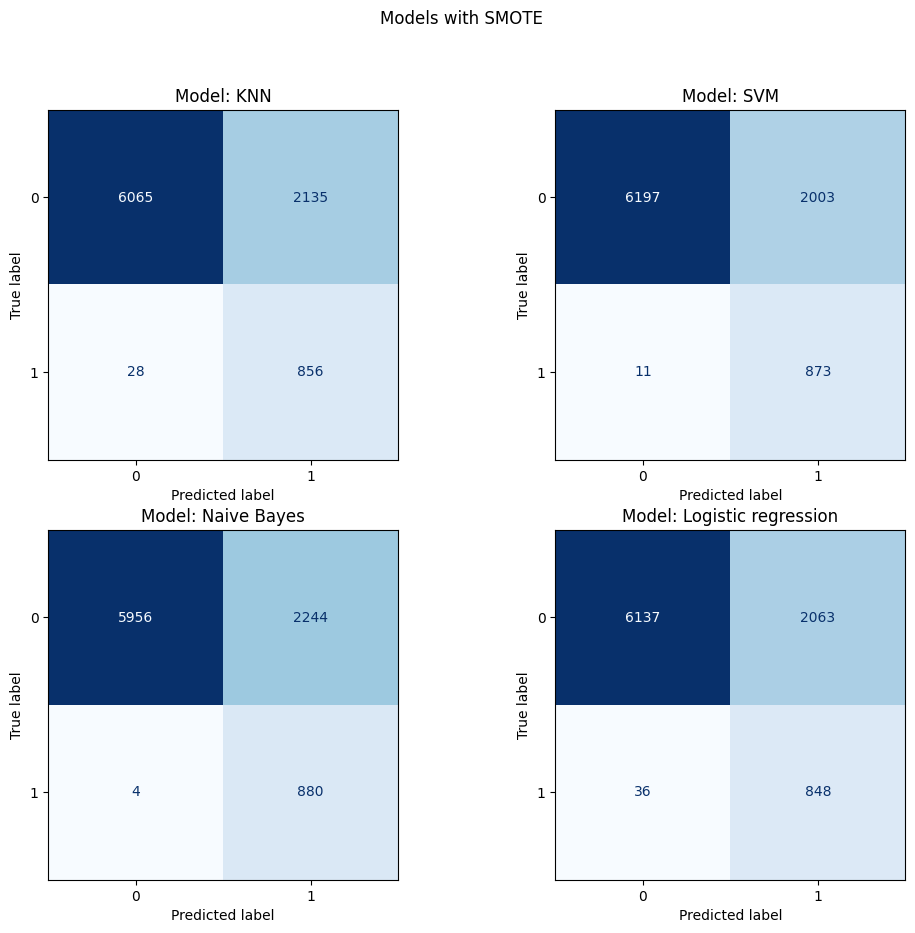

In [126]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for ax, (alg_name, model_info) in zip(axes, models_reports.items()):
    model = model_info["model"]
    report = model_info["report"]

    predict = model.predict(X_test)

    cm = confusion_matrix(y_test, predict)

    matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    matrix.plot(cmap="Blues", ax=ax, colorbar=False)

    ax.set_title(f"Model: {alg_name}")

fig.suptitle("Models with SMOTE")


Text(0.5, 0.98, 'Logistic Regression')

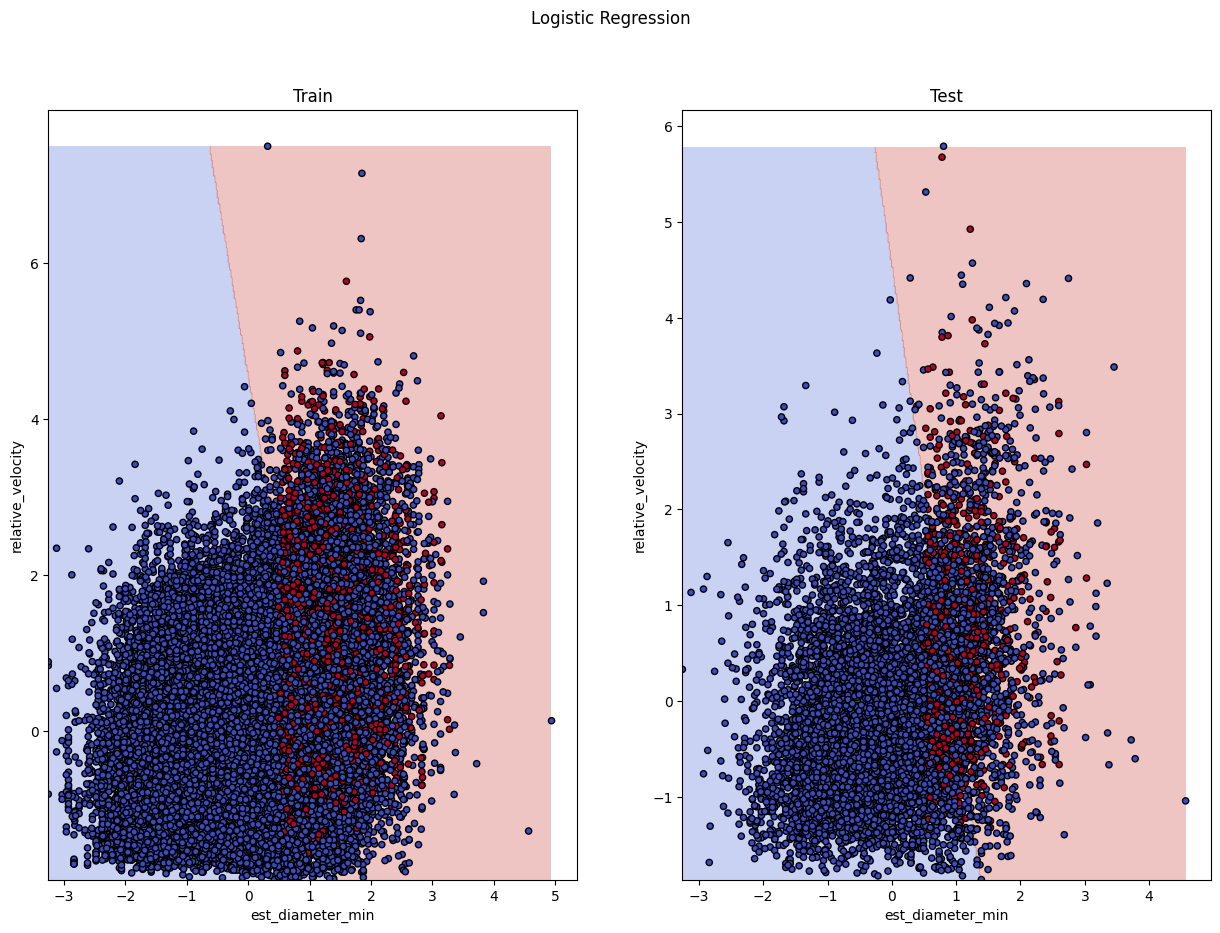

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train, y_train), (X_test, y_test)]):

    feat_x = X["est_diameter_min"]
    feat_y = X["relative_velocity"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["est_diameter_min"] = xx.ravel()
    grid_data["relative_velocity"] = yy.ravel()

    Z = log_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)


    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm', s=20)
    ax.set_xlabel('est_diameter_min')
    ax.set_ylabel('relative_velocity')

axes[0].set_title("Train")
axes[1].set_title("Test")
fig.suptitle("Logistic Regression")


Text(0.5, 0.98, 'SVM')

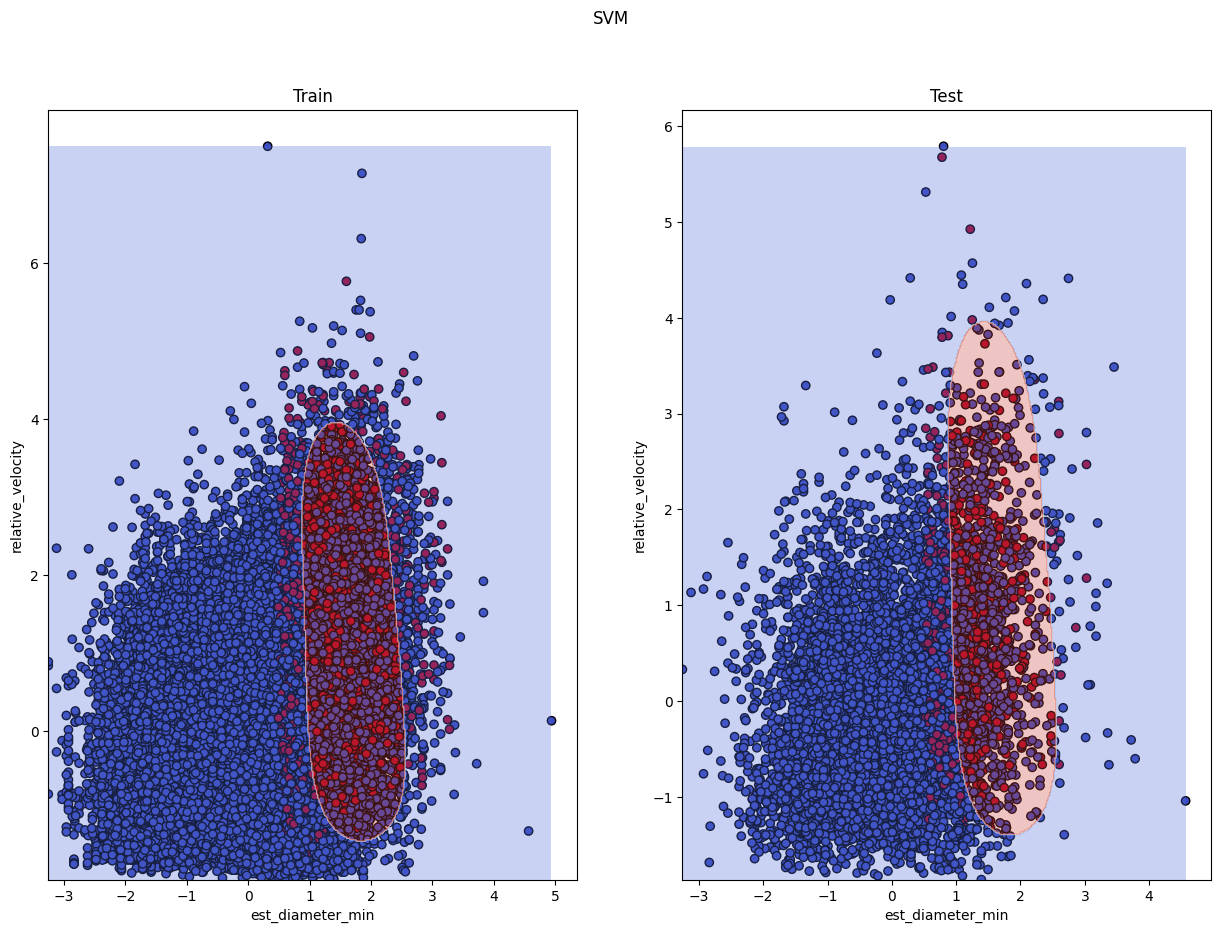

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train, y_train), (X_test, y_test)]):

    feat_x = X["est_diameter_min"]
    feat_y = X["relative_velocity"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["est_diameter_min"] = xx.ravel()
    grid_data["relative_velocity"] = yy.ravel()

    Z = svm_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm')
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.set_xlabel('est_diameter_min')
    ax.set_ylabel('relative_velocity')

axes[0].set_title("Train")
axes[1].set_title("Test")

plt.suptitle("SVM")

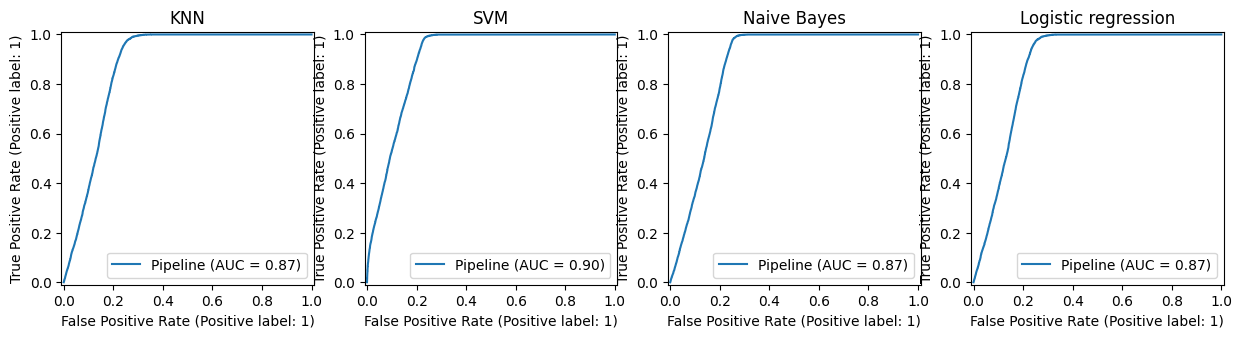

In [97]:
fix, axes = plt.subplots(1, 4, figsize=(15, 10))

for ax, (alg_name, model_info) in zip(axes, models_reports.items()):
    model = model_info["model"]
    RocCurveDisplay.from_estimator(model, X_train, y_train, ax=ax)
    ax.set_title(alg_name)

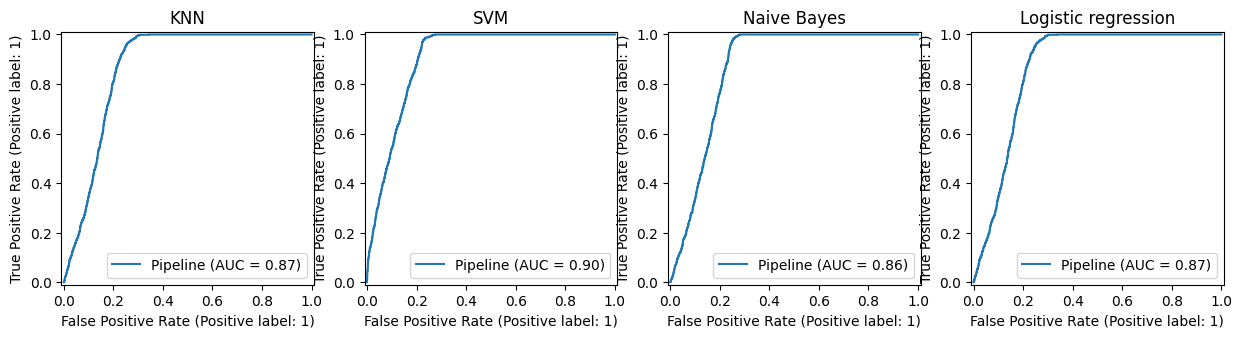

In [98]:
fix, axes = plt.subplots(1, 4, figsize=(15, 10))

for ax, (alg_name, model_info) in zip(axes, models_reports.items()):
    model = model_info["model"]
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(alg_name)

Text(0.5, 0.98, 'KNN')

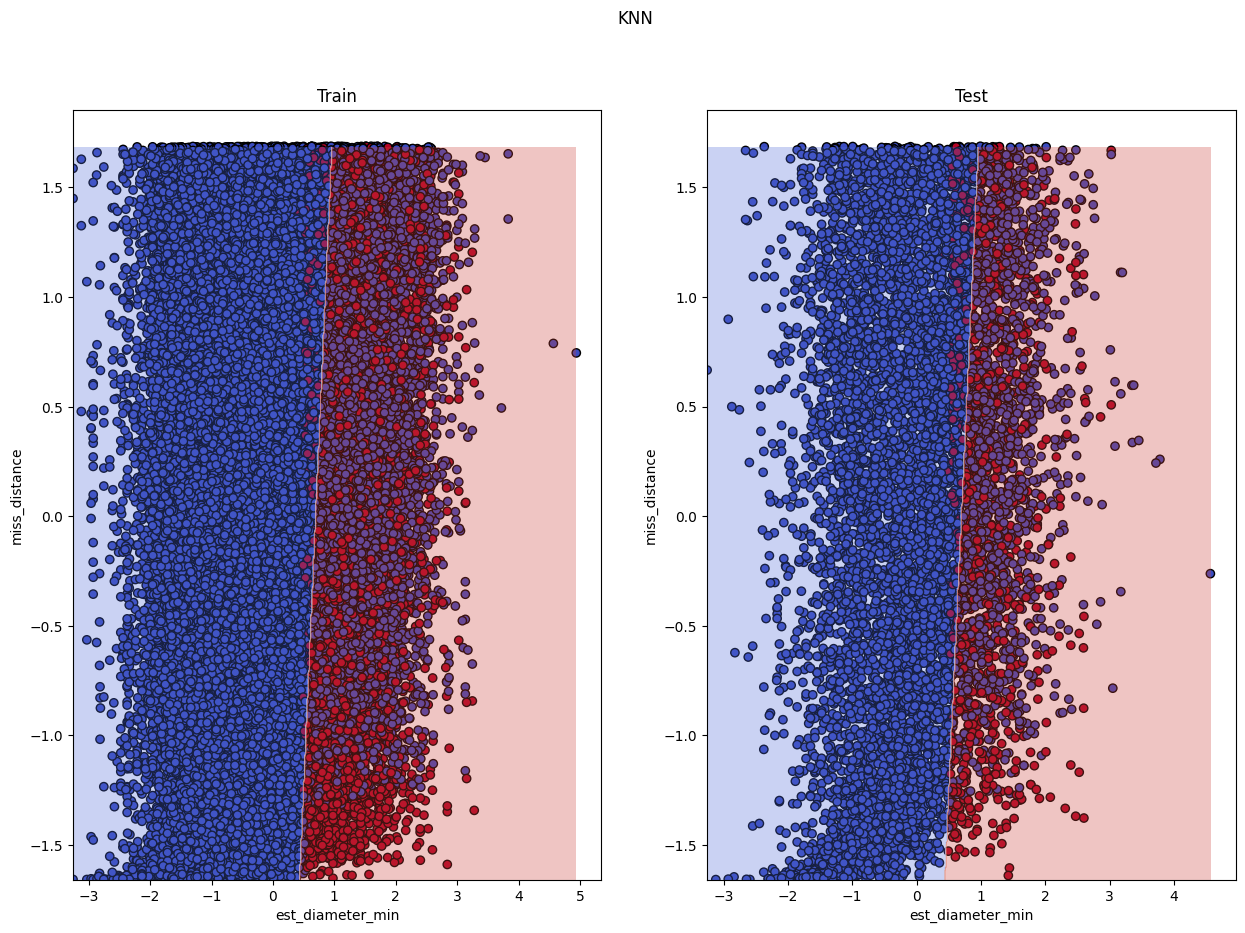

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train, y_train), (X_test, y_test)]):

    feat_x = X["est_diameter_min"]
    feat_y = X["miss_distance"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["est_diameter_min"] = xx.ravel()
    grid_data["miss_distance"] = yy.ravel()

    Z = knn_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm')
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.set_xlabel('est_diameter_min')
    ax.set_ylabel('miss_distance')

axes[0].set_title("Train")
axes[1].set_title("Test")

plt.suptitle("KNN")

Text(0.5, 0.98, 'Naive Bayes model')

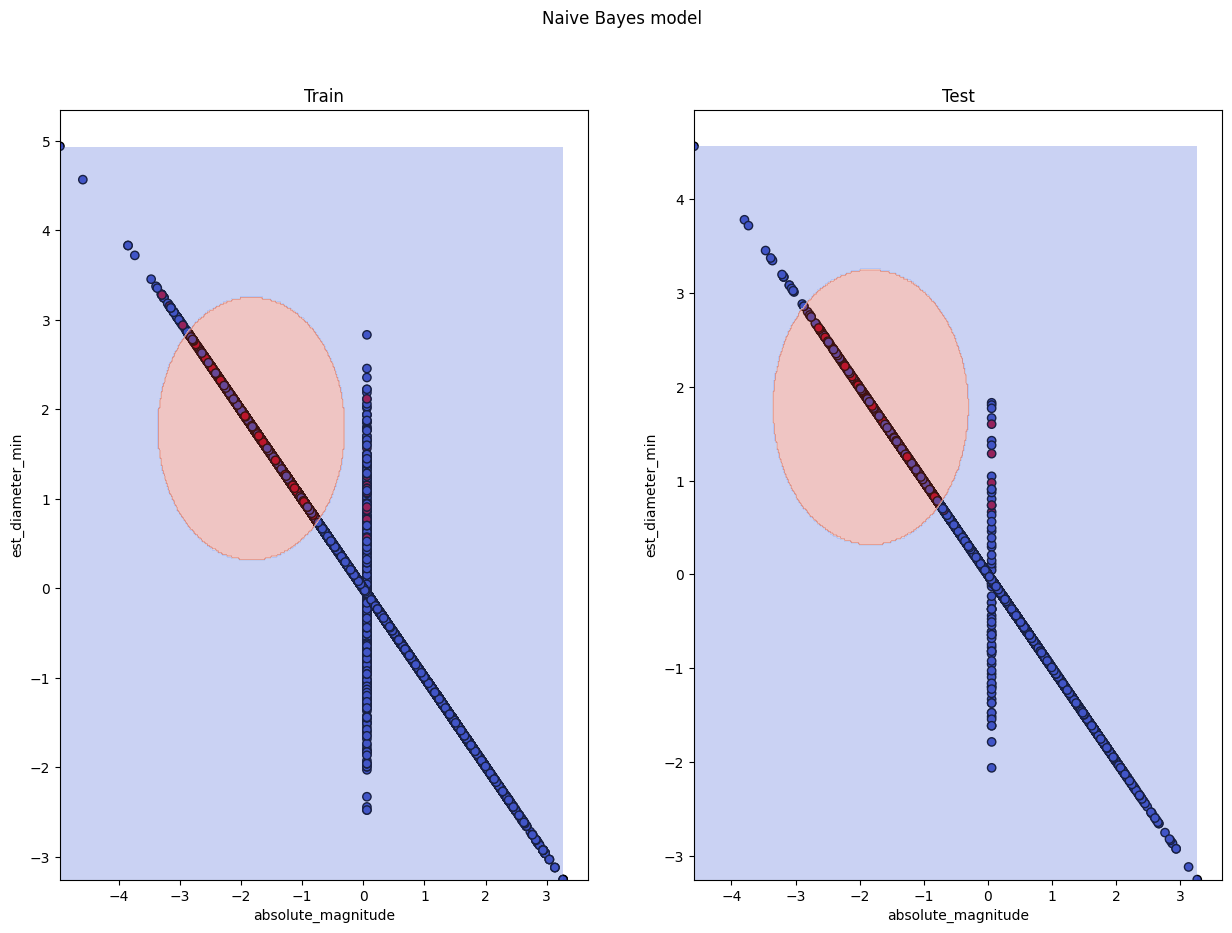

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train, y_train), (X_test, y_test)]):

    feat_x = X["absolute_magnitude"]
    feat_y = X["est_diameter_min"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["absolute_magnitude"] = xx.ravel()
    grid_data["est_diameter_min"] = yy.ravel()

    Z = naive_bayes_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm')
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.set_xlabel('absolute_magnitude')
    ax.set_ylabel('est_diameter_min')

axes[0].set_title("Train")
axes[1].set_title("Test")

plt.suptitle("Naive Bayes model")

Text(0.5, 0.98, 'Naive Bayes')

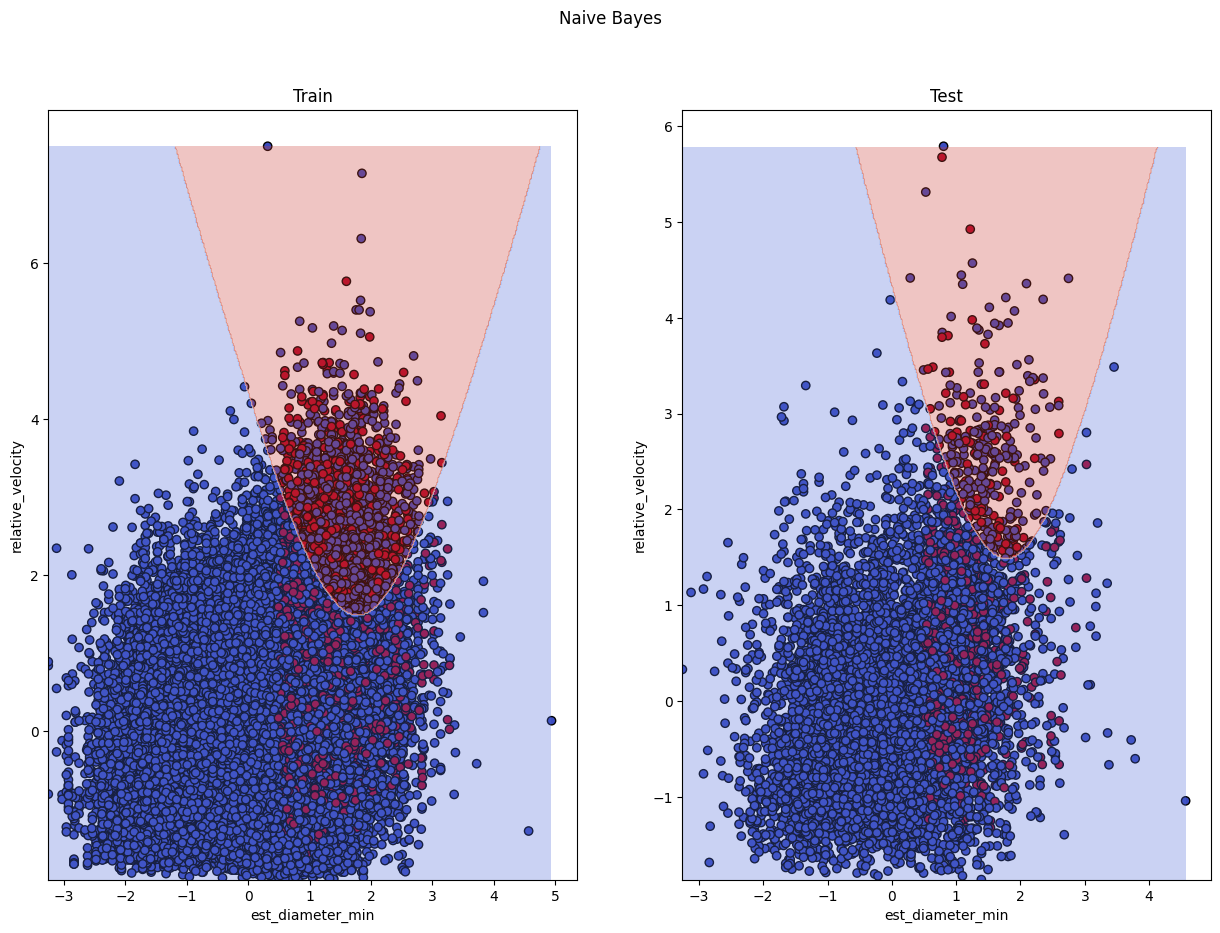

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train, y_train), (X_test, y_test)]):

    feat_x = X["est_diameter_min"]
    feat_y = X["relative_velocity"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["est_diameter_min"] = xx.ravel()
    grid_data["relative_velocity"] = yy.ravel()

    Z = naive_bayes_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm')
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.set_xlabel('est_diameter_min')
    ax.set_ylabel('relative_velocity')

axes[0].set_title("Train")
axes[1].set_title("Test")

plt.suptitle("Naive Bayes")

## Обучение моделей без балансировки

В силу того, что при применении метода SMOTE практически все модели оказались переобучены, то попробуем обучить те же модели на тренировочных данных без балансировки.

In [9]:
unbalanced_models_grid = {
    "Logistic regression":{
        "model": LogisticRegression,
        "param_grid":
            {
                "C": [0.1, 1, 10, 100],
                "penalty": ["l2"],
                "solver": ["lbfgs"]

            }
    },
    "KNN_euclidean":
        {
            "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["euclidean"]
            }
        },
    "KNN_manhattan":{
            "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["manhattan"]
            }
        },
    "KNN_chebyshev":{
        "model": KNeighborsClassifier,
            "param_grid":{
                "n_neighbors": [3, 5, 11, 19],
                "weights": ["uniform", "distance"],
                "metric": ["chebyshev"]
            }
    },

    "Naive_Bayes":{
        "model": GaussianNB,
        "param_grid":{
            "var_smoothing": np.logspace(-3, 1, num=20)
        }
    },

    "SVM_linear":{
        "model": LinearSVC,
        "param_grid":{
            "C": [0.1, 1, 10],
        }
    },
    "SVM_poly":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale"],
            "cache_size": [4000],
            "kernel": ["poly"],
            "degree": [2]
        }
    },

    "SVM_rbf":{
        "model": SVC,
        "param_grid":{
            "C": [0.1, 1, 10],
            "gamma": ["scale"],
            "kernel": ["rbf"],
            "cache_size": [4000],
        }
    },
}

In [12]:
unbalanced_val_models = train_models_with_val(X_train, y_train, X_val, y_val, unbalanced_models_grid)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

In [23]:
for alg, search_info in unbalanced_val_models.items():
    for type_of_search, model_info in search_info.items():
        model = model_info["model"]
        y_test_predicted = model.predict(X_test)
        y_train_predicted = model.predict(X_train)

        name_of_model = f"Unbalanced {alg} with validation ({type_of_search})"

        input_metrics_into_the_train_test_table(name_of_model,
                              y_train_predicted, y_train,
                              y_test_predicted, y_test)
train_test_table[train_test_table.index.str.startswith("Unbalanced")]

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall
Unbalanced Logistic regression with validation (GridSearch),0.13,0.8933,0.3102,0.0792,0.12,0.8927,0.2922,0.0724
Unbalanced Logistic regression with validation (RandomSearch),0.13,0.8933,0.3102,0.0792,0.12,0.8927,0.2922,0.0724
Unbalanced Logistic regression with validation (Optuna),0.13,0.8932,0.3099,0.0792,0.12,0.8927,0.2922,0.0724
Unbalanced KNN_euclidean with validation (GridSearch),1.00,0.9996,0.9980,0.9983,0.41,0.8970,0.4628,0.3654
Unbalanced KNN_euclidean with validation (RandomSearch),1.00,0.9996,0.9980,0.9983,0.41,0.8970,0.4628,0.3654
Unbalanced KNN_euclidean with validation (Optuna),1.00,0.9996,0.9980,0.9983,0.41,0.8970,0.4628,0.3654
Unbalanced KNN_manhattan with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.42,0.8991,0.4765,0.3790
Unbalanced KNN_manhattan with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.42,0.8991,0.4765,0.3790
Unbalanced KNN_manhattan with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.42,0.8991,0.4765,0.3790
Unbalanced KNN_chebyshev with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.37,0.8900,0.4191,0.3371


После обучения моделей на несбалансированной выборке метрики моделей значительно ухудшились. Так, метрика Recall не превышает 0.8 для всех моделей, тогда как при применении SMOTE значение метрики Recall превышало 0.9.

In [128]:
unb_svm_rbf_model = unbalanced_val_models["SVM_rbf"]["Optuna"]["model"]
unb_knn_model = unbalanced_val_models["KNN_manhattan"]["Optuna"]["model"]
unb_naive_model = unbalanced_val_models["Naive_Bayes"]["Optuna"]["model"]
unb_log_model = unbalanced_val_models["Logistic regression"]["Optuna"]["model"]

Text(0.5, 0.98, 'Models on the unbalanced data')

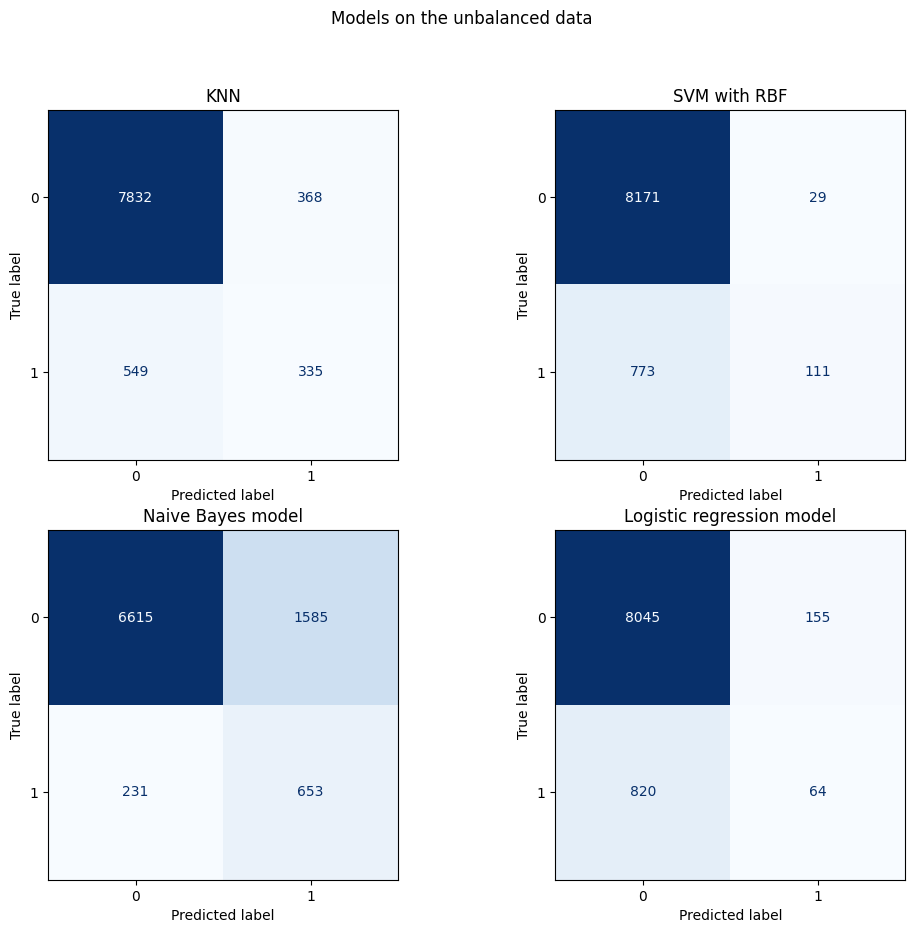

In [130]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for ax, (alg_name, model) in zip(axes,
                                 {"KNN": unb_knn_model,
                                  "SVM with RBF": unb_svm_rbf_model,
                                  "Naive Bayes model": unb_naive_model,
                                  "Logistic regression model": unb_log_model}.items()):

    predict = model.predict(X_test)

    cm = confusion_matrix(y_test, predict)

    matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    matrix.plot(cmap="Blues", ax=ax, colorbar=False)

    ax.set_title(alg_name)

fig.suptitle("Models on the unbalanced data")

## Обучение моделей с under-sampling стратегией

In [34]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)


X_train_under, y_train_under = rus.fit_resample(X_train, y_train)


print(y_train_under.value_counts())

hazardous
0    7072
1    7072
Name: count, dtype: int64


In [31]:
undersamplered_val_models = train_models_with_val(X_train_under, y_train_under, X_val, y_val,unbalanced_models_grid)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

In [32]:
for alg, search_info in undersamplered_val_models.items():
    for type_of_search, model_info in search_info.items():
        model = model_info["model"]
        y_test_predicted = model.predict(X_test)
        y_train_predicted = model.predict(X_train)

        name_of_model = f"Undersamplered {alg} with validation ({type_of_search})"

        input_metrics_into_the_train_test_table(name_of_model,
                              y_train_predicted, y_train,
                              y_test_predicted, y_test)
train_test_table[train_test_table.index.str.startswith("Undersamplered")]

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall
Undersamplered Logistic regression with validation (GridSearch),0.46,0.7900,0.3056,0.9102,0.45,0.7904,0.3028,0.8857
Undersamplered Logistic regression with validation (RandomSearch),0.46,0.7900,0.3056,0.9102,0.45,0.7904,0.3028,0.8857
Undersamplered Logistic regression with validation (Optuna),0.46,0.7902,0.3058,0.9099,0.45,0.7905,0.3026,0.8835
Undersamplered KNN_euclidean with validation (GridSearch),0.46,0.7740,0.2998,0.9900,0.46,0.7755,0.3000,0.9796
Undersamplered KNN_euclidean with validation (RandomSearch),0.46,0.7740,0.2998,0.9900,0.46,0.7755,0.3000,0.9796
Undersamplered KNN_euclidean with validation (Optuna),0.51,0.8106,0.3394,1.0000,0.47,0.7856,0.3071,0.9581
Undersamplered KNN_manhattan with validation (GridSearch),0.47,0.7781,0.3040,0.9926,0.47,0.7797,0.3049,0.9876
Undersamplered KNN_manhattan with validation (RandomSearch),0.47,0.7781,0.3040,0.9926,0.47,0.7797,0.3049,0.9876
Undersamplered KNN_manhattan with validation (Optuna),0.50,0.8121,0.3367,0.9596,0.47,0.8043,0.3199,0.8982
Undersamplered KNN_chebyshev with validation (GridSearch),0.49,0.7975,0.3246,1.0000,0.46,0.7728,0.2968,0.9751


Заметим, что при использовании стратегии under-sampling модели перестали переобучаться. Кроме того, значения метрики Recall улучшилось - так, для модели SVM с радиальным ядром эта метрика увеличилась до 0.9898.

In [134]:
undersamplered_svm_rbf_model = undersamplered_val_models["SVM_rbf"]["Optuna"]["model"]
undersamplered_knn_model = undersamplered_val_models["KNN_manhattan"]["Optuna"]["model"]
undersamplered_naive_model = undersamplered_val_models["Naive_Bayes"]["Optuna"]["model"]
undersamplered_log_model = undersamplered_val_models["Logistic regression"]["Optuna"]["model"]

Text(0.5, 0.98, 'Models on the undersamplered data')

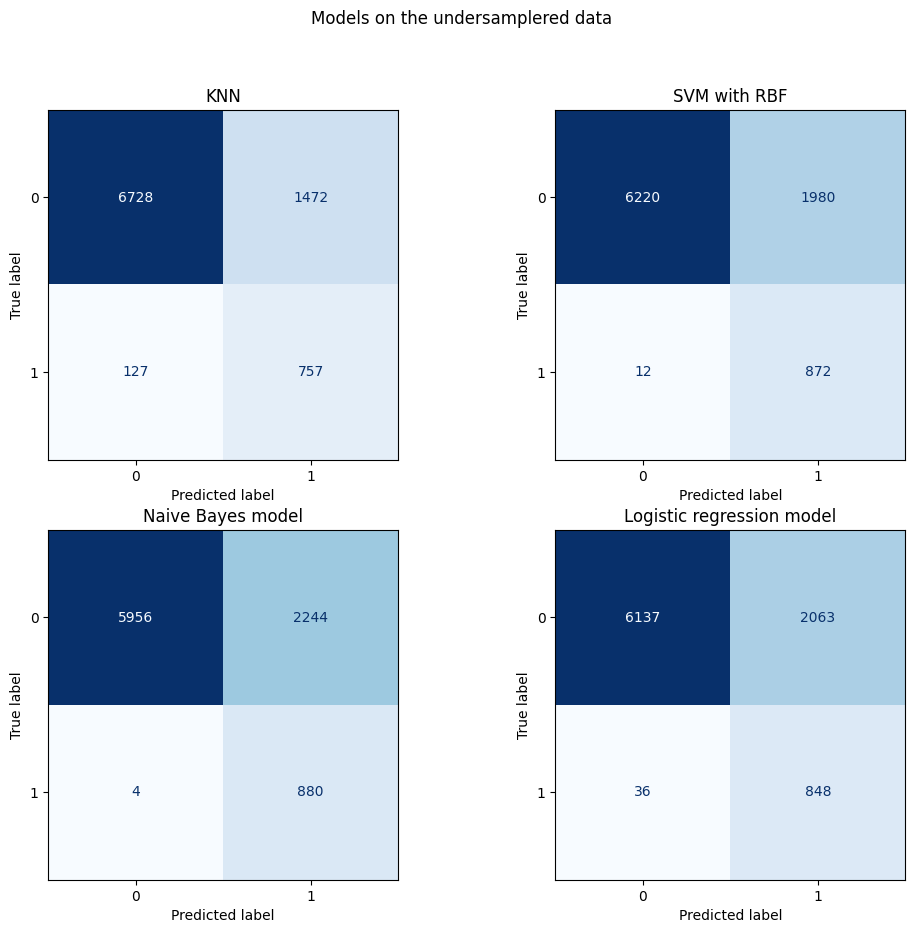

In [135]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for ax, (alg_name, model) in zip(axes,
                                 {"KNN": undersamplered_knn_model,
                                  "SVM with RBF": undersamplered_svm_rbf_model,
                                  "Naive Bayes model": undersamplered_naive_model,
                                  "Logistic regression model": undersamplered_log_model}.items()):

    predict = model.predict(X_test)

    cm = confusion_matrix(y_test, predict)

    matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    matrix.plot(cmap="Blues", ax=ax, colorbar=False)

    ax.set_title(alg_name)

fig.suptitle("Models on the undersamplered data")

## Обучение моделей с комбинированной стратегией SMOTEENN

Попробуем применить комбинацию стратегий over- и undersampling.

In [36]:
from imblearn.combine import SMOTEENN

sme = SMOTEENN(random_state=RANDOM_STATE)

X_train_sme, y_train_sme = sme.fit_resample(X_train, y_train)
print(y_train_sme.value_counts())

hazardous
1    60072
0    54530
Name: count, dtype: int64


In [37]:
undersamplered_val_models = train_models_with_val(X_train_sme, y_train_sme, X_val, y_val,unbalanced_models_grid)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

In [103]:
for alg, search_info in undersamplered_val_models.items():
    for type_of_search, model_info in search_info.items():
        model = model_info["model"]
        y_test_predicted = model.predict(X_test)
        y_train_predicted = model.predict(X_train_sme)

        name_of_model = f"SMOTEENN {alg} with validation ({type_of_search})"

        input_metrics_into_the_train_test_table(name_of_model,
                              y_train_predicted, y_train_sme,
                              y_test_predicted, y_test)
train_test_table[train_test_table.index.str.startswith("SMOTEENN")]

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall
SMOTEENN Logistic regression with validation (GridSearch),0.94,0.9360,0.9063,0.9792,0.45,0.7689,0.2913,0.9593
SMOTEENN Logistic regression with validation (RandomSearch),0.94,0.9360,0.9063,0.9792,0.45,0.7689,0.2913,0.9593
SMOTEENN Logistic regression with validation (Optuna),0.94,0.9360,0.9063,0.9791,0.45,0.7689,0.2913,0.9593
SMOTEENN KNN_euclidean with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8272,0.3405,0.8281
SMOTEENN KNN_euclidean with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8272,0.3405,0.8281
SMOTEENN KNN_euclidean with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.48,0.8217,0.3366,0.8575
SMOTEENN KNN_manhattan with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8288,0.3424,0.8247
SMOTEENN KNN_manhattan with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8288,0.3424,0.8247
SMOTEENN KNN_manhattan with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.49,0.8240,0.3396,0.8563
SMOTEENN KNN_chebyshev with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8241,0.3367,0.8326


Модели с применением данной стратегии показали себя лучше всего. Так, для этих моделей не характерно переобучение, как при использовании SMOTE-стратегии, но при этом значение метрик лучше, чем при применении under-sampling. Так, наивная байесовская модель имеет наиболее высокий показатель метрики Recall - 0.9955.

Попробуем обучить эти модели с применением кросс-валидации.

In [79]:
def train_models_with_cross_val_and_smoteenn(X_train, y_train, models_config):

    result={}

    skf = StratifiedKFold(n_splits=10, random_state=RANDOM_STATE, shuffle=True)
    smote = SMOTEENN(random_state=RANDOM_STATE)

    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        model_obj = model_info["model"]
        prefixed_param_grid = {f"model__{k}": v for k, v in param_grid.items()}

        pipeline = Pipeline([('smote', smote), ('model', model_obj())])
        grid_search_model = GridSearchCV(
            param_grid=prefixed_param_grid,
            estimator= pipeline,
            scoring="f1",
            cv=skf
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=prefixed_param_grid,
            estimator=pipeline,
            scoring="f1",
            random_state=RANDOM_STATE,
            cv=skf
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            current_pipe = Pipeline([
                ('smote', smote),
                ('model', model_obj(**trial_params))
            ])

            score = cross_val_score(current_pipe, X_train, y_train, cv=skf, scoring='f1').mean()
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=5, show_progress_bar=False)

        final_optuna_pipe = Pipeline([
                ('smote', smote),
                ('model', model_obj(**study.best_params))
            ])
        final_optuna_pipe.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": final_optuna_pipe,
            "best_params": study.best_params
        }

    return result

In [81]:
smoteenn_cv_models = train_models_with_cross_val_and_smoteenn(X_train, y_train, unbalanced_models_grid)

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

In [104]:
for alg, search_info in smoteenn_cv_models.items():
    for type_of_search, model_info in search_info.items():
        model = model_info["model"]
        y_test_predicted = model.predict(X_test)
        y_train_predicted = model.predict(X_train)

        name_of_model = f"SMOTEENN {alg} with cross-validation ({type_of_search})"

        input_metrics_into_the_train_test_table(name_of_model,
                              y_train_predicted, y_train,
                              y_test_predicted, y_test)
train_test_table[train_test_table.index.str.startswith("SMOTEENN")]

,Train Data F1,Train Data Accuracy,Train Data Precision,Train Data Recall,Test Data F1,Test Data Accuracy,Test Data Precision,Test Data Recall
SMOTEENN Logistic regression with validation (GridSearch),0.94,0.9360,0.9063,0.9792,0.45,0.7689,0.2913,0.9593
SMOTEENN Logistic regression with validation (RandomSearch),0.94,0.9360,0.9063,0.9792,0.45,0.7689,0.2913,0.9593
SMOTEENN Logistic regression with validation (Optuna),0.94,0.9360,0.9063,0.9791,0.45,0.7689,0.2913,0.9593
SMOTEENN KNN_euclidean with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8272,0.3405,0.8281
SMOTEENN KNN_euclidean with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8272,0.3405,0.8281
SMOTEENN KNN_euclidean with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.48,0.8217,0.3366,0.8575
SMOTEENN KNN_manhattan with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8288,0.3424,0.8247
SMOTEENN KNN_manhattan with validation (RandomSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8288,0.3424,0.8247
SMOTEENN KNN_manhattan with validation (Optuna),1.00,1.0000,1.0000,1.0000,0.49,0.8240,0.3396,0.8563
SMOTEENN KNN_chebyshev with validation (GridSearch),1.00,1.0000,1.0000,1.0000,0.48,0.8241,0.3367,0.8326


Видим, что в результате применения кросс-валидации метрики остались примерно теми же.

Лучшими моделями оказались модели наивной байесовской регрессии, SVM с радиальным ядром, SVM с линейным ядром и логистическая регрессия.

In [106]:
svm_linear_model = smoteenn_cv_models["SVM_linear"]["Optuna"]["model"]
svm_rbf_model = smoteenn_cv_models["SVM_rbf"]["Optuna"]["model"]
naive_model = smoteenn_cv_models["Naive_Bayes"]["Optuna"]["model"]
log_model = smoteenn_cv_models["Logistic regression"]["Optuna"]["model"]

In [107]:
get_cv_report(log_model, X_train, y_train)

,Accuracy,Prec.,Recall,F1
Fold 1,0.7701,0.2942,0.9745,0.4520
Fold 2,0.7740,0.2989,0.9830,0.4584
Fold 3,0.7703,0.2950,0.9788,0.4533
Fold 4,0.7651,0.2904,0.9802,0.4481
Fold 5,0.7669,0.2913,0.9745,0.4486
Fold 6,0.7643,0.2879,0.9661,0.4437
Fold 7,0.7725,0.2969,0.9760,0.4554
Fold 8,0.7658,0.2912,0.9788,0.4488
Fold 9,0.7677,0.2921,0.9745,0.4494
Fold 10,0.7660,0.2906,0.9745,0.4477


In [111]:
get_cv_report(naive_model, X_train, y_train)

,Accuracy,Recall,Prec.,F1
0,0.7546,0.9972,0.2836,0.4416
1,0.7575,0.9972,0.2860,0.4445
2,0.7511,0.9929,0.2801,0.4370
3,0.7500,0.9958,0.2796,0.4366
4,0.7520,0.9972,0.2814,0.4390
5,0.7490,0.9901,0.2781,0.4342
6,0.7540,0.9944,0.2830,0.4406
7,0.7522,0.9958,0.2817,0.4391
8,0.7541,0.9972,0.2831,0.4410
9,0.7470,0.9958,0.2773,0.4338


In [112]:
get_cv_report(svm_rbf_model, X_train, y_train)

,Accuracy,Recall,Prec.,F1
0,0.7791,0.9929,0.3050,0.4666
1,0.7804,0.9929,0.3061,0.4680
2,0.7742,0.9943,0.3004,0.4614
3,0.7723,0.9943,0.2986,0.4593
4,0.7772,0.9972,0.3036,0.4655
5,0.7739,0.9901,0.2997,0.4601
6,0.7800,0.9929,0.3061,0.4679
7,0.7749,0.9929,0.3012,0.4622
8,0.7754,0.9943,0.3016,0.4628
9,0.7758,0.9943,0.3020,0.4633


In [113]:
get_cv_report(svm_linear_model, X_train, y_train)

,Accuracy,Recall,Prec.,F1
0,0.7625,0.9802,0.2881,0.4454
1,0.7661,0.9887,0.2923,0.4513
2,0.7615,0.9859,0.2880,0.4458
3,0.7579,0.9830,0.2846,0.4414
4,0.7593,0.9802,0.2854,0.4421
5,0.7582,0.9717,0.2834,0.4388
6,0.7646,0.9845,0.2908,0.4490
7,0.7586,0.9788,0.2850,0.4414
8,0.7616,0.9788,0.2873,0.4442
9,0.7582,0.9760,0.2840,0.4399


In [114]:
get_most_important_metrics(X_val, y_val, naive_model)

,feature,importance_mean,importance_std
3,miss_distance,-0.001255,0.000410
2,relative_velocity,-0.001541,0.001072
4,absolute_magnitude,-0.043835,0.001777
1,est_diameter_max,-0.044562,0.002100
0,est_diameter_min,-0.044628,0.002095


In [115]:
get_most_important_metrics(X_val, y_val, log_model)

,feature,importance_mean,importance_std
0,est_diameter_min,0.005196,0.002300
3,miss_distance,0.005130,0.001084
1,est_diameter_max,0.002708,0.001616
4,absolute_magnitude,0.001277,0.000475
2,relative_velocity,-0.000330,0.001177


In [116]:
get_most_important_metrics(X_val, y_val, svm_linear_model)

,feature,importance_mean,importance_std
0,est_diameter_min,0.045156,0.001356
3,miss_distance,0.005945,0.000778
2,relative_velocity,0.000859,0.001155
4,absolute_magnitude,-0.003104,0.000189
1,est_diameter_max,-0.013628,0.001981


In [117]:
get_most_important_metrics(X_val, y_val, svm_rbf_model)

,feature,importance_mean,importance_std
3,miss_distance,0.003479,0.000495
2,relative_velocity,0.000462,0.002547
0,est_diameter_min,-0.045531,0.002513
4,absolute_magnitude,-0.050837,0.003205
1,est_diameter_max,-0.055438,0.002248


Text(0.5, 0.98, 'Logistic regression model')

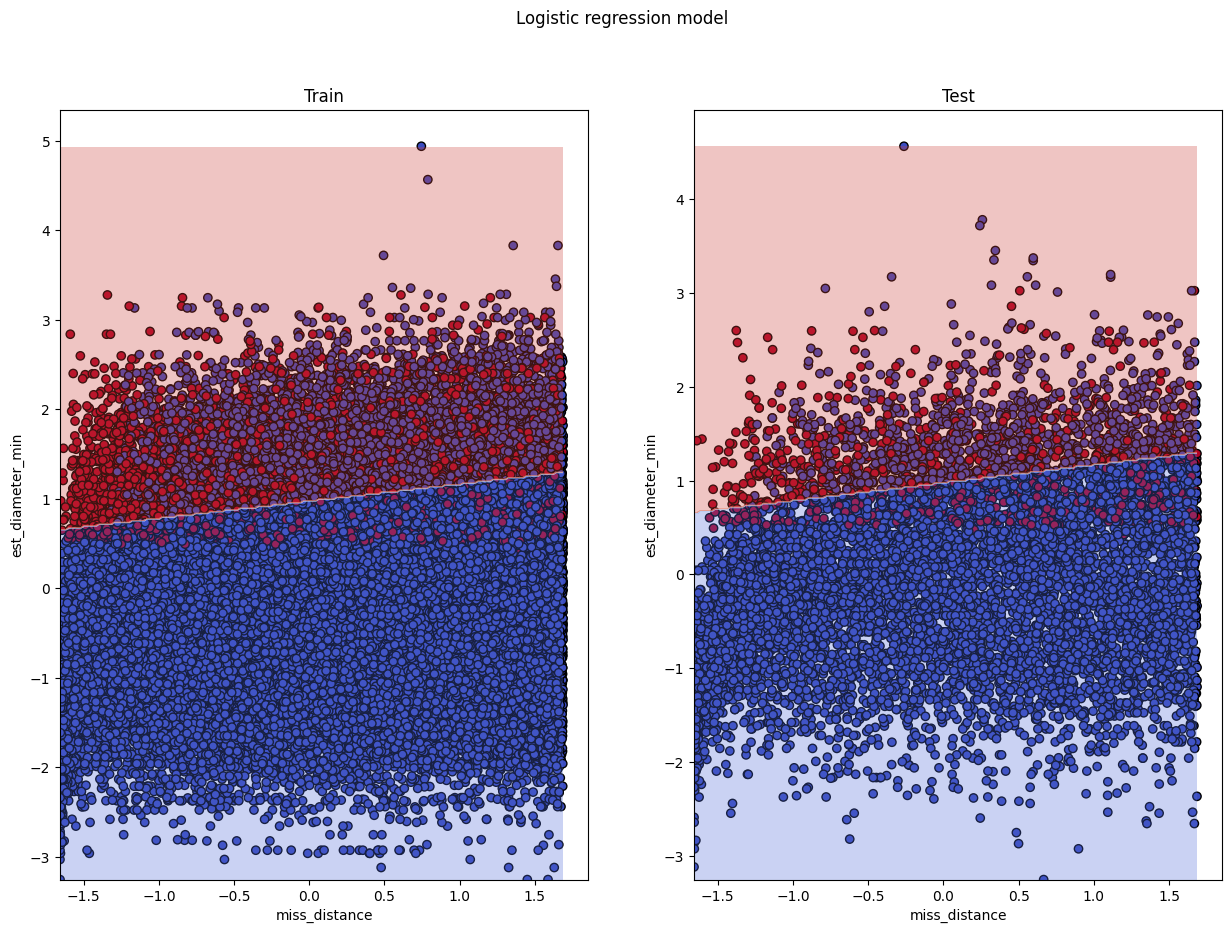

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train, y_train), (X_test, y_test)]):

    feat_x = X["miss_distance"]
    feat_y = X["est_diameter_min"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["miss_distance"] = xx.ravel()
    grid_data["est_diameter_min"] = yy.ravel()

    Z = log_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm')
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.set_xlabel('miss_distance')
    ax.set_ylabel('est_diameter_min')

axes[0].set_title("Train")
axes[1].set_title("Test")

plt.suptitle("Logistic regression model")

Text(0.5, 0.98, 'SVM linear model')

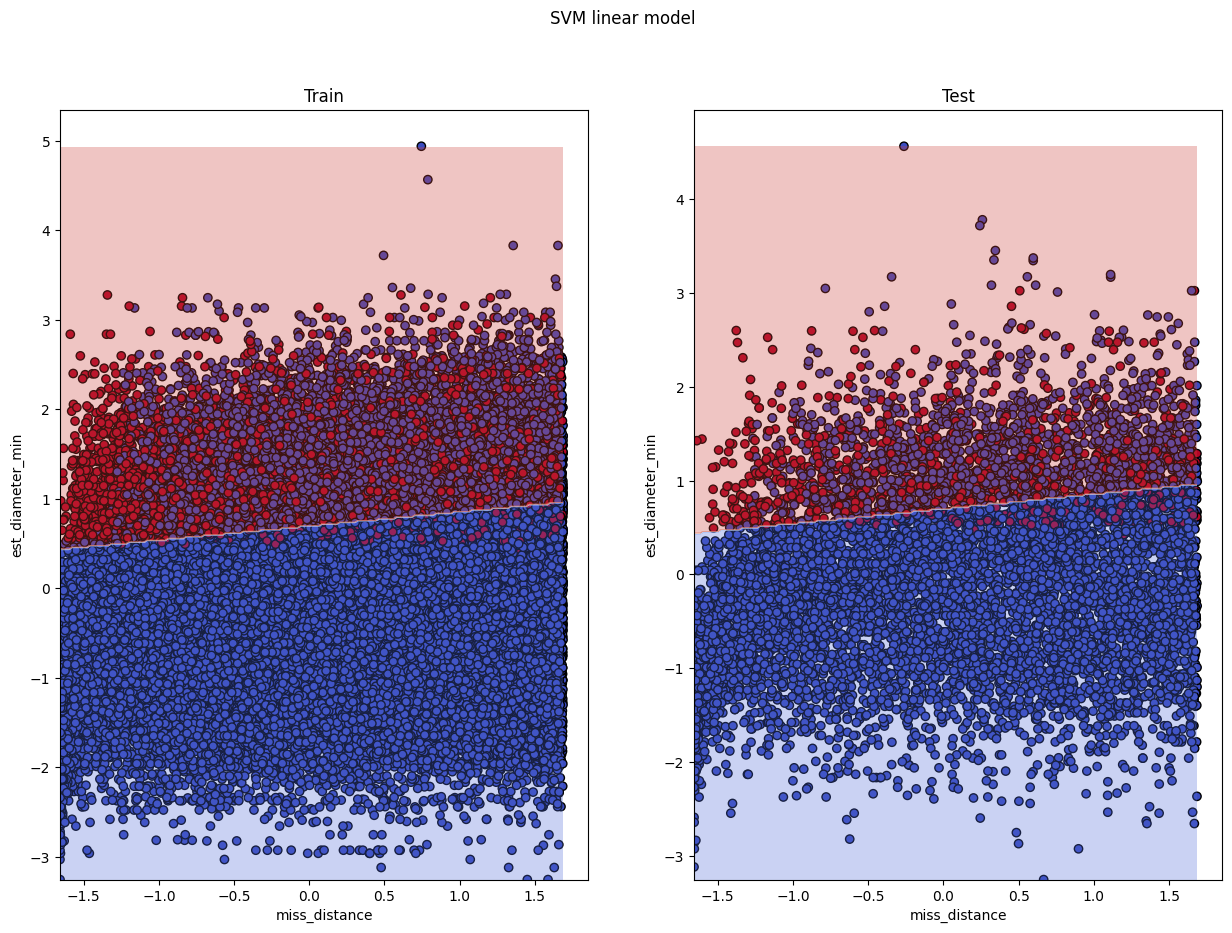

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train, y_train), (X_test, y_test)]):

    feat_x = X["miss_distance"]
    feat_y = X["est_diameter_min"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["miss_distance"] = xx.ravel()
    grid_data["est_diameter_min"] = yy.ravel()

    Z = svm_linear_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm')
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.set_xlabel('miss_distance')
    ax.set_ylabel('est_diameter_min')

axes[0].set_title("Train")
axes[1].set_title("Test")

plt.suptitle("SVM linear model")

Text(0.5, 0.98, 'Naive Bayes model')

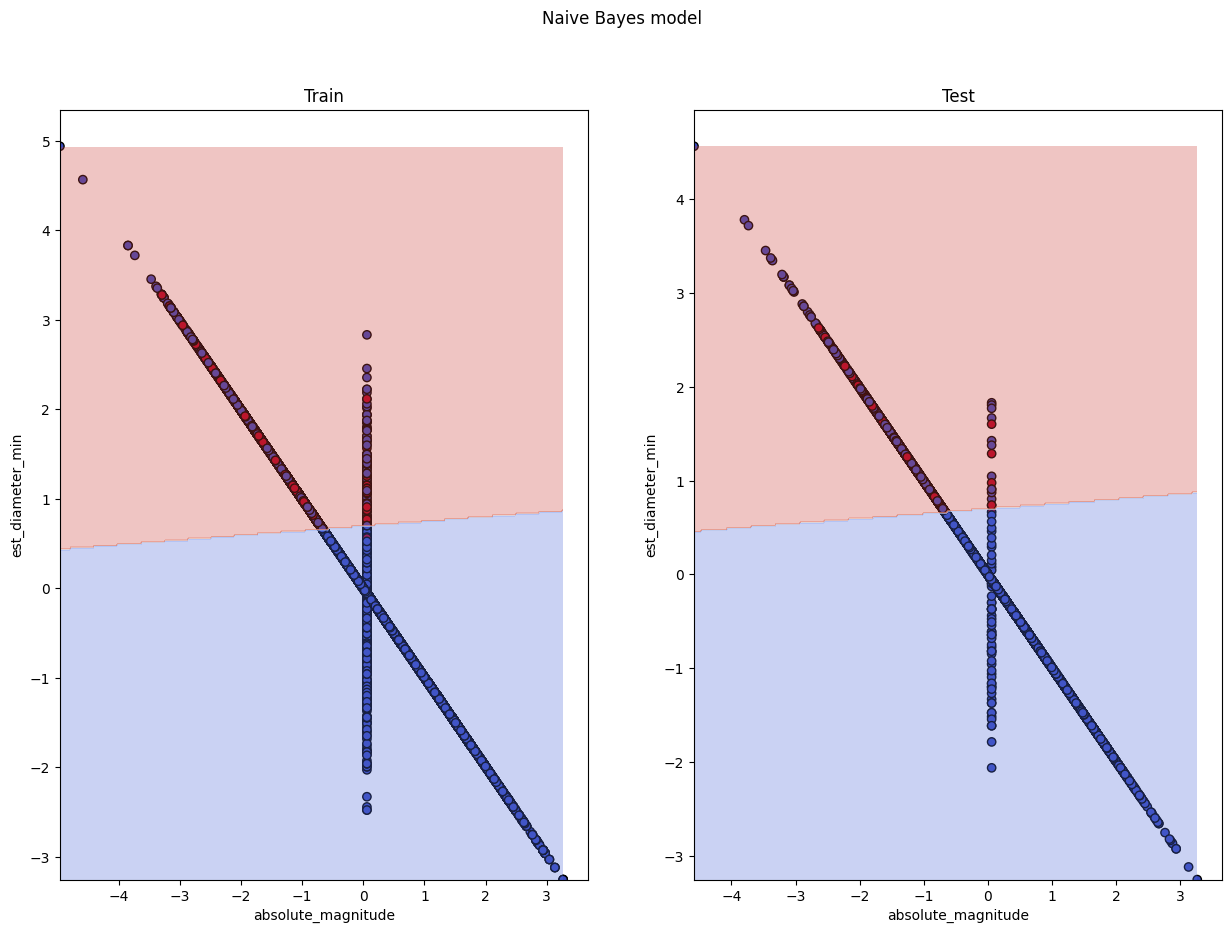

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

for ax, (X, y) in zip(axes, [(X_train, y_train), (X_test, y_test)]):

    feat_x = X["absolute_magnitude"]
    feat_y = X["est_diameter_min"]


    h = 0.02
    xx, yy = np.meshgrid(np.arange(feat_x.min(), feat_x.max(), h), np.arange(feat_y.min(), feat_y.max(), h))

    grid_data = pd.DataFrame(np.tile(X.mean().values, (len(xx.ravel()), 1)), columns=X_test.columns)

    grid_data["absolute_magnitude"] = xx.ravel()
    grid_data["est_diameter_min"] = yy.ravel()

    Z = svm_linear_model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    ax.scatter(feat_x, feat_y, c=y, edgecolors='k', cmap='coolwarm')
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.set_xlabel('absolute_magnitude')
    ax.set_ylabel('est_diameter_min')

axes[0].set_title("Train")
axes[1].set_title("Test")

plt.suptitle("Naive Bayes model")

Text(0.5, 0.98, 'Models with SMOTEENN')

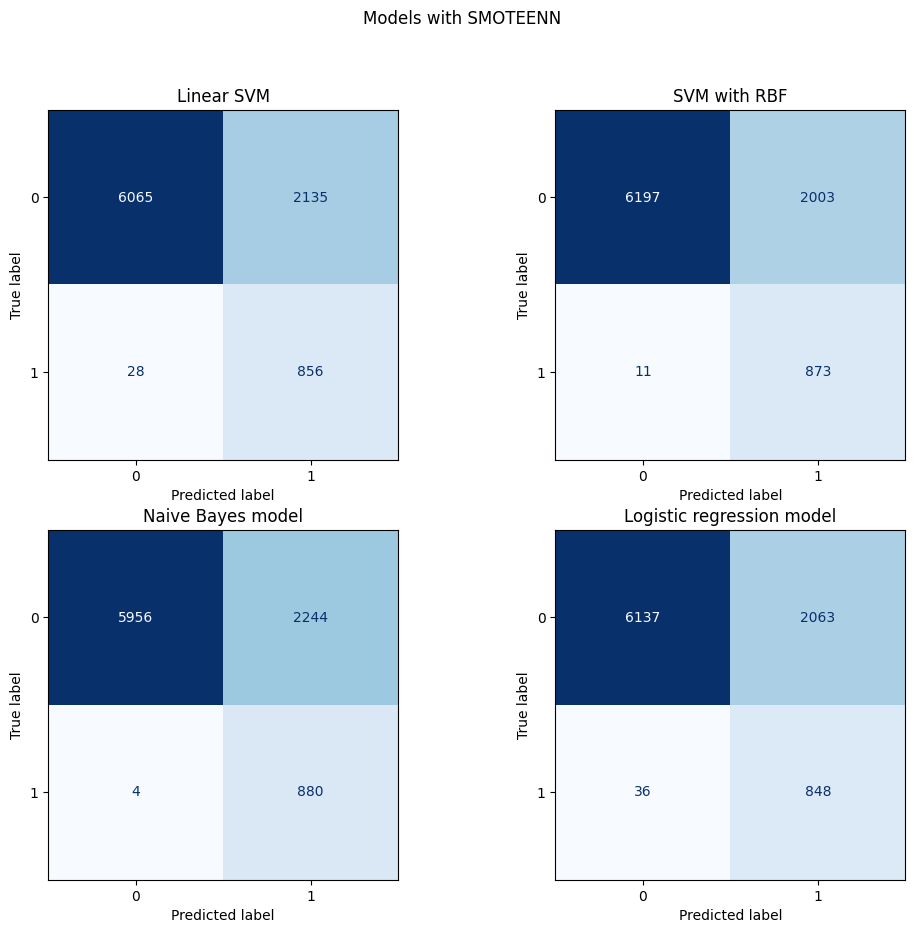

In [125]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for ax, (alg_name, model_info) in zip(axes,
                                 {"Linear SVM": svm_linear_model,
                                  "SVM with RBF": svm_rbf_model,
                                  "Naive Bayes model": naive_bayes_model,
                                  "Logistic regression model": log_model}.items()):

    model = model_info["model"]

    predict = model.predict(X_test)

    cm = confusion_matrix(y_test, predict)

    matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    matrix.plot(cmap="Blues", ax=ax, colorbar=False)

    ax.set_title(alg_name)

fig.suptitle("Models with SMOTEENN")

## Сравнение кастомного kNN и kNN из sklearn

Сравним время работы кастомного kNN и kNN из sklearn.

In [144]:
import time
from metrics import kNN

start = time.time()

custom_knn = kNN()
custom_knn.fit(X_train_sme, y_train_sme)
predict = custom_knn.predict(X_test)

finish = time.time()
print(finish - start)
get_metrics(y_test, predict, print_results=True)

34.66729283332825
F1: 0.48
Accuracy: 0.8181
Precision: 0.3339
Recall: 0.8733


[0.48, 0.8181, 0.3339, 0.8733]

In [145]:
start = time.time()

knn = KNeighborsClassifier()
knn.fit(X_train_sme, y_train_sme)
predict = knn.predict(X_test)

finish = time.time()
print(finish - start)
get_metrics(y_test, predict, print_results=True)

0.07507514953613281
F1: 0.48
Accuracy: 0.8181
Precision: 0.3339
Recall: 0.8733


[0.48, 0.8181, 0.3339, 0.8733]

## Вывод